In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data = pd.read_csv("FeatureSelection_global_heat_index.csv")

clean1 = data[data['Hour']<6]
clean2 = data[data['Hour']>18]
data = data.drop(clean1.index, axis=0)
data = data.drop(clean2.index, axis=0)

x = data.iloc[:,:-1]
y = data.iloc[:,-1]

from sklearn.preprocessing import MinMaxScaler
x = pd.DataFrame(MinMaxScaler().fit_transform(x))

In [3]:
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(x,y)

ExtraTreesClassifier()

In [10]:
col = data.columns[0:-1]
feature_imp = pd.Series(model.feature_importances_, index = col)
feature_imp

Year                 0.026541
Month                0.043331
Day                  0.108688
Hour                 0.112204
Dew Point            0.088524
Temperature          0.138329
Pressure             0.124416
Relative Humidity    0.124140
Wind Direction       0.116589
Wind Speed           0.117238
dtype: float64

<Axes: >

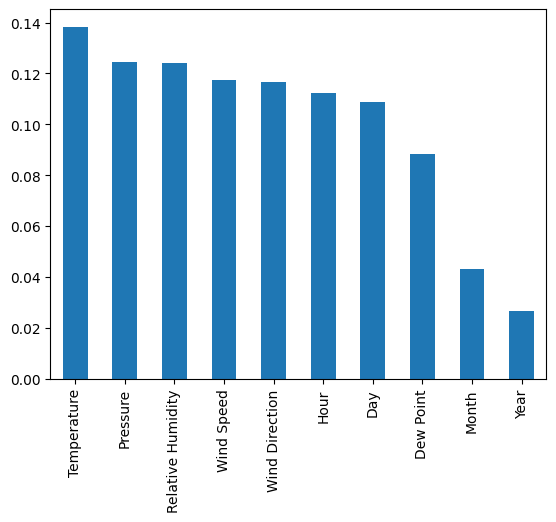

In [11]:
feature_imp.nlargest(10).plot(kind = 'bar')